In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Matplotlib is building the font cache; this may take a moment.


Pandas version: 3.0.5
NumPy version: 2.5.2


In [4]:
PROJECT_DIR = Path.cwd().parent

DATA_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Raw data directory:", DATA_DIR)
print("Processed data directory:", PROCESSED_DIR)
print("Raw data directory exists:", DATA_DIR.exists())

Project directory: d:\Resume Projects\Ecommerce-Customer-Analytics
Raw data directory: d:\Resume Projects\Ecommerce-Customer-Analytics\data\raw
Processed data directory: d:\Resume Projects\Ecommerce-Customer-Analytics\data\processed
Raw data directory exists: True


In [5]:
customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")
order_items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")
order_payments = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")
order_reviews = pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv")
products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")

print("All six datasets loaded successfully.")

All six datasets loaded successfully.


In [6]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "products": products
}

for name, df in datasets.items():
    print(f"{name:15} | Rows: {df.shape[0]:>8,} | Columns: {df.shape[1]:>2}")

customers       | Rows:   99,441 | Columns:  5
orders          | Rows:   99,441 | Columns:  8
order_items     | Rows:  112,650 | Columns:  7
order_payments  | Rows:  103,886 | Columns:  5
order_reviews   | Rows:   99,224 | Columns:  7
products        | Rows:   32,951 | Columns:  9


In [7]:
for name, df in datasets.items():
    print(f"\n--- {name} ---")
    print("Shape:", df.shape)
    print("Duplicate rows:", df.duplicated().sum())
    print("Missing values:", df.isna().sum().sum())


--- customers ---
Shape: (99441, 5)
Duplicate rows: 0
Missing values: 0

--- orders ---
Shape: (99441, 8)
Duplicate rows: 0
Missing values: 4908

--- order_items ---
Shape: (112650, 7)
Duplicate rows: 0
Missing values: 0

--- order_payments ---
Shape: (103886, 5)
Duplicate rows: 0
Missing values: 0

--- order_reviews ---
Shape: (99224, 7)
Duplicate rows: 0
Missing values: 145903

--- products ---
Shape: (32951, 9)
Duplicate rows: 0
Missing values: 2448


In [8]:
# Create working copies for cleaning
customers_clean = customers.copy()
orders_clean = orders.copy()
order_items_clean = order_items.copy()
order_payments_clean = order_payments.copy()
order_reviews_clean = order_reviews.copy()
products_clean = products.copy()

print("Working copies created.")

Working copies created.


In [9]:
order_date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in order_date_columns:
    orders_clean[col] = pd.to_datetime(
        orders_clean[col],
        errors="coerce"
    )

print(orders_clean[order_date_columns].dtypes)

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


In [10]:
review_date_columns = [
    "review_creation_date",
    "review_answer_timestamp"
]

for col in review_date_columns:
    order_reviews_clean[col] = pd.to_datetime(
        order_reviews_clean[col],
        errors="coerce"
    )

print(order_reviews_clean[review_date_columns].dtypes)

review_creation_date       datetime64[us]
review_answer_timestamp    datetime64[us]
dtype: object


In [12]:
print("Missing order timestamps:")
print(orders_clean[order_date_columns].isna().sum())

print("\nMissing review timestamps:")
print(order_reviews_clean[review_date_columns].isna().sum())

Missing order timestamps:
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Missing review timestamps:
review_creation_date       0
review_answer_timestamp    0
dtype: int64


In [ ]:
# Check for exact duplicate rows in each dataset
for name, df in {
    "customers": customers_clean,
    "orders": orders_clean,
    "order_items": order_items_clean,
    "order_payments": order_payments_clean,
    "order_reviews": order_reviews_clean,
    "products": products_clean
}.items():
    print(f"{name:15} | Exact duplicate rows: {df.duplicated().sum():,}")

customers       | Exact duplicate rows: 0
orders          | Exact duplicate rows: 0
order_items     | Exact duplicate rows: 0
order_payments  | Exact duplicate rows: 0
order_reviews   | Exact duplicate rows: 0
products        | Exact duplicate rows: 0


In [14]:
# check whether the expected keys are unique:
key_checks = {
    "customers": (customers_clean, "customer_id"),
    "orders": (orders_clean, "order_id"),
    "products": (products_clean, "product_id")
}

for name, (df, key) in key_checks.items():
    print(
        f"{name:15} | Duplicate {key}: "
        f"{df[key].duplicated().sum():,}"
    )

customers       | Duplicate customer_id: 0
orders          | Duplicate order_id: 0
products        | Duplicate product_id: 0


In [15]:
# Check the line-item and payment keys:
print(
    "Duplicate order item keys:",
    order_items_clean.duplicated(
        subset=["order_id", "order_item_id"]
    ).sum()
)

print(
    "Duplicate payment keys:",
    order_payments_clean.duplicated(
        subset=["order_id", "payment_sequential"]
    ).sum()
)

Duplicate order item keys: 0
Duplicate payment keys: 0


In [ ]:
# Investigate missing values
# a reusable function to report the number and percentage of missing values in every column.
def missing_summary(df):
    result = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percentage": df.isna().mean() * 100
    })

    result = result.sort_values(
        "missing_percentage",
        ascending=False
    )

    return result[result["missing_count"] > 0].round(2)

In [ ]:
missing_summary(products_clean)
missing_summary(orders_clean)
missing_summary(order_reviews_clean)
# to check missing values in each dataset, you can call the `missing_summary` function for each DataFrame. For example:
# missing_summary(customers_clean)


How should we handle missing values?
Situation	What to do
Missing delivery date for a canceled order	Keep it; this can be expected
Missing product description or photo count	Keep the product; fill only if a specific analysis requires it
Missing review comment	Keep the review; the score may still be valid
Missing product category	Preserve it as unknown for category reporting
Missing purchase timestamp	Investigate; exclude from analyses that require a valid purchase date
Missing key ID	Investigate before deciding whether a row can be used
Rule: don't use dropna() on an entire DataFrame without a specific reason. It may remove valid orders or products.

In [21]:
# Validate numeric columns
print("Order item numeric checks")
print("Negative prices:", (order_items_clean["price"] < 0).sum())
print("Negative freight:", (order_items_clean["freight_value"] < 0).sum())

print("\nPayment checks")
print("Negative payments:", (order_payments_clean["payment_value"] < 0).sum())

print("\nReview score distribution")
print(order_reviews_clean["review_score"].value_counts(dropna=False).sort_index())

Order item numeric checks
Negative prices: 0
Negative freight: 0

Payment checks
Negative payments: 0

Review score distribution
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


In [22]:
invalid_reviews = order_reviews_clean[
    ~order_reviews_clean["review_score"].between(1, 5)
    & order_reviews_clean["review_score"].notna()
]

print("Invalid review scores:", len(invalid_reviews))

Invalid review scores: 0


In [23]:
# Check delivery timestamp logic
# Delivery before purchase
delivery_before_purchase = orders_clean[
    orders_clean["order_delivered_customer_date"].notna()
    & orders_clean["order_purchase_timestamp"].notna()
    & (
        orders_clean["order_delivered_customer_date"]
        < orders_clean["order_purchase_timestamp"]
    )
]

print("Delivered before purchase:", len(delivery_before_purchase))

Delivered before purchase: 0


In [24]:
# check delivered orders missing their delivery date:
delivered_missing_date = orders_clean[
    (orders_clean["order_status"] == "delivered")
    & orders_clean["order_delivered_customer_date"].isna()
]

print("Delivered orders missing actual delivery date:", len(delivered_missing_date))

Delivered orders missing actual delivery date: 8


In [25]:
# data-cleaning summary
clean_datasets = {
    "customers": customers_clean,
    "orders": orders_clean,
    "order_items": order_items_clean,
    "order_payments": order_payments_clean,
    "order_reviews": order_reviews_clean,
    "products": products_clean
}

cleaning_summary = []

for name, df in clean_datasets.items():
    cleaning_summary.append({
        "table": name,
        "rows": len(df),
        "columns": len(df.columns),
        "missing_cells": int(df.isna().sum().sum()),
        "exact_duplicate_rows": int(df.duplicated().sum())
    })

cleaning_summary = pd.DataFrame(cleaning_summary)
cleaning_summary

,table,rows,columns,missing_cells,exact_duplicate_rows
0,customers,99441,5,0,0
1,orders,99441,8,4908,0
2,order_items,112650,7,0,0
3,order_payments,103886,5,0,0
4,order_reviews,99224,7,145903,0
5,products,32951,9,2448,0


In [ ]:
#aggregate the item lines so that every order appears at most once.
item_totals = (
    order_items_clean
    .groupby("order_id", as_index=False)
    .agg(
        item_revenue=("price", "sum"),
        freight_revenue=("freight_value", "sum"),
        item_lines=("order_item_id", "count"),
        distinct_products=("product_id", "nunique"),
        distinct_sellers=("seller_id", "nunique")
    )
)

item_totals.head()

What each column means:
- item_revenue: sum of product-line prices, excluding freight.
- freight_revenue: sum of freight charges.
- item_lines: number of product lines, not necessarily the physical unit count.
- distinct_products: number of different product IDs in the order.
- distinct_sellers: number of different sellers contributing to the order.

In [ ]:
# Check the grain 
print("Rows:", len(item_totals))
print("Unique orders:", item_totals["order_id"].nunique())
print("Duplicate order IDs:", item_totals["order_id"].duplicated().sum())

#The number of rows should equal the number of unique order_id values, and duplicate order IDs should be zero.

Rows: 98666
Unique orders: 98666
Duplicate order IDs: 0


In [28]:
# Build an order-level payments summary
# Payments can also have multiple records per order. Aggregate them before joining.
payment_totals = (
    order_payments_clean
    .groupby("order_id", as_index=False)
    .agg(
        payment_total=("payment_value", "sum"),
        payment_records=("payment_sequential", "count"),
        payment_methods=("payment_type", "nunique"),
        max_installments=("payment_installments", "max")
    )
)

payment_totals.head()

,order_id,payment_total,payment_records,payment_methods,max_installments
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1,1,2
1,00018f77f2f0320c557190d7a144bdd3,259.83,1,1,3
2,000229ec398224ef6ca0657da4fc703e,216.87,1,1,5
3,00024acbcdf0a6daa1e931b038114c75,25.78,1,1,2
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1,1,3


In [29]:
# validate the result
print("Rows:", len(payment_totals))
print("Unique orders:", payment_totals["order_id"].nunique())
print("Duplicate order IDs:", payment_totals["order_id"].duplicated().sum())

Rows: 99440
Unique orders: 99440
Duplicate order IDs: 0


In [ ]:
# Build an order-level review summary
# To avoid multiplying order rows, we'll summarize reviews by order.
review_totals = (
    order_reviews_clean
    .groupby("order_id", as_index=False)
    .agg(
        average_review_score=("review_score", "mean"),
        review_records=("review_id", "nunique"),
        review_count=("review_score", "count")
    )
)

review_totals.head()

The distinction between the review columns is useful:
- review_records: distinct review IDs.
- review_count: non-missing review scores.
- average_review_score: average of available scores for that order.
If an order has multiple review records, its order-level score is the average of those scores. We'll use this definition when comparing delivery performance with customer reviews.

In [31]:
# Validate the grain
print("Rows:", len(review_totals))
print("Unique orders:", review_totals["order_id"].nunique())
print("Duplicate order IDs:", review_totals["order_id"].duplicated().sum())

Rows: 98673
Unique orders: 98673
Duplicate order IDs: 0


In [32]:
# Build the master order-level dataset
order_master = (
    orders_clean
    .merge(
        customers_clean[
            ["customer_id", "customer_unique_id",
             "customer_city", "customer_state"]
        ],
        on="customer_id",
        how="left",
        validate="one_to_one"
    )
    .merge(
        item_totals,
        on="order_id",
        how="left",
        validate="one_to_one"
    )
    .merge(
        payment_totals,
        on="order_id",
        how="left",
        validate="one_to_one"
    )
    .merge(
        review_totals,
        on="order_id",
        how="left",
        validate="one_to_one"
    )
)

order_master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,item_revenue,freight_revenue,item_lines,distinct_products,distinct_sellers,payment_total,payment_records,payment_methods,max_installments,average_review_score,review_records,review_count
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,29.99,8.72,1.00,1.00,1.00,38.71,3.00,2.00,1.00,4.00,1.00,1.00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA,118.70,22.76,1.00,1.00,1.00,141.46,1.00,1.00,1.00,4.00,1.00,1.00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,159.90,19.22,1.00,1.00,1.00,179.12,1.00,1.00,3.00,5.00,1.00,1.00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,45.00,27.20,1.00,1.00,1.00,72.20,1.00,1.00,1.00,5.00,1.00,1.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,19.90,8.72,1.00,1.00,1.00,28.62,1.00,1.00,1.00,5.00,1.00,1.00


What does validate="one_to_one" do?
It tells Pandas to raise an error if the join keys aren't unique on either side of the merge. This helps catch accidental row multiplication rather than silently producing incorrect metrics.
We're using how="left" so that orders remain in the dataset even if they have no matching item, payment, or review summary.

In [ ]:
# check master dataset grain
print("Rows in orders:", len(orders_clean))
print("Rows in order_master:", len(order_master))
print("Unique order IDs:", order_master["order_id"].nunique())
print("Duplicate order IDs:", order_master["order_id"].duplicated().sum())

# The row count should remain equal to the original orders table's row count.

Rows in orders: 99441
Rows in order_master: 99441
Unique order IDs: 99441
Duplicate order IDs: 0


In [34]:
# Create a delivered-orders analysis dataset    
delivered_orders = order_master[
    (order_master["order_status"] == "delivered")
    & order_master["order_purchase_timestamp"].notna()
    & order_master["item_revenue"].notna()
].copy()

print("Delivered analysis rows:", len(delivered_orders))
print(
    "Unique orders:",
    delivered_orders["order_id"].nunique()
)

Delivered analysis rows: 96478
Unique orders: 96478


This filter is intentional. Document that our main sales analysis excludes non-delivered orders and delivered orders without a usable purchase timestamp or item summary. We should not silently treat missing revenue as zero.

In [ ]:
# Add useful analysis columns
delivered_orders["order_month"] = (
    delivered_orders["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

delivered_orders["delivery_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

delivered_orders["delivery_delay_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 60 * 60)

delivered_orders["is_late"] = (
    delivered_orders["order_delivered_customer_date"].notna()
    & delivered_orders["order_estimated_delivery_date"].notna()
    & (
        delivered_orders["order_delivered_customer_date"]
        > delivered_orders["order_estimated_delivery_date"]
    )
)

Interpretation:
- order_month: month of purchase, not month of delivery.
- delivery_days: elapsed days between purchase and customer delivery.
- delivery_delay_days: positive means delivered after the estimated date; negative means earlier.
- is_late: True only when both dates exist and actual delivery is later than estimated.
Missing delivery dates remain missing; we don't fill them with zero.

In [36]:
# Build a customer-level summary
customer_summary = (
    delivered_orders
    .groupby("customer_unique_id", as_index=False)
    .agg(
        delivered_orders=("order_id", "nunique"),
        first_purchase=("order_purchase_timestamp", "min"),
        latest_purchase=("order_purchase_timestamp", "max"),
        total_item_revenue=("item_revenue", "sum"),
        total_freight=("freight_revenue", "sum")
    )
)

customer_summary["repeat_customer"] = (
    customer_summary["delivered_orders"] >= 2
)

customer_summary["days_between_first_and_latest"] = (
    customer_summary["latest_purchase"]
    - customer_summary["first_purchase"]
).dt.days

customer_summary.head()

,customer_unique_id,delivered_orders,first_purchase,latest_purchase,total_item_revenue,total_freight,repeat_customer,days_between_first_and_latest
0,0000366f3b9a7992bf8c76cfdf3221e2,1,2018-05-10 10:56:27,2018-05-10 10:56:27,129.90,12.00,False,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,2018-05-07 11:11:27,2018-05-07 11:11:27,18.90,8.29,False,0
2,0000f46a3911fa3c0805444483337064,1,2017-03-10 21:05:03,2017-03-10 21:05:03,69.00,17.22,False,0
3,0000f6ccb0745a6a4b88665a16c9f078,1,2017-10-12 20:29:41,2017-10-12 20:29:41,25.99,17.63,False,0
4,0004aac84e0df4da2b147fca70cf8255,1,2017-11-14 19:45:42,2017-11-14 19:45:42,180.00,16.89,False,0


In [37]:
# check customer summary grain
print("Rows:", len(customer_summary))
print(
    "Unique customers:",
    customer_summary["customer_unique_id"].nunique()
)
print(
    "Duplicate customer IDs:",
    customer_summary["customer_unique_id"].duplicated().sum()
)

Rows: 93358
Unique customers: 93358
Duplicate customer IDs: 0


In [38]:
# Final validation of the master dataset
assert order_master["order_id"].is_unique
assert item_totals["order_id"].is_unique
assert payment_totals["order_id"].is_unique
assert review_totals["order_id"].is_unique
assert customer_summary["customer_unique_id"].is_unique

assert len(order_master) == len(orders_clean)

print("All grain validation checks passed.")

All grain validation checks passed.


In [39]:
# Analyze sales and order values
# A. Calculate the key business KPIs
total_item_revenue = delivered_orders["item_revenue"].sum()
total_freight = delivered_orders["freight_revenue"].sum()
total_orders = delivered_orders["order_id"].nunique()

aov = total_item_revenue / total_orders

median_order_value = delivered_orders["item_revenue"].median()

print(f"Total item revenue: {total_item_revenue:,.2f}")
print(f"Total freight: {total_freight:,.2f}")
print(f"Total delivered orders: {total_orders:,}")
print(f"Average order value: {aov:,.2f}")
print(f"Median order value: {median_order_value:,.2f}")

Total item revenue: 13,221,498.11
Total freight: 2,198,275.64
Total delivered orders: 96,478
Average order value: 137.04
Median order value: 86.57


Interpretation:
- Item revenue is the sum of product prices, excluding freight.
- AOV is item revenue divided by the number of eligible delivered orders.
- Median order value is the middle order value after sorting orders from lowest to highest.

Why calculate both mean and median? A few high-value orders can pull the mean upward. If the mean is substantially greater than the median, order values may be right-skewed.

In [40]:
# B. Examine the distribution of order values
order_value_stats = delivered_orders["item_revenue"].describe()

print(order_value_stats)

count   96,478.00
mean       137.04
std        209.05
min          0.85
25%         45.90
50%         86.57
75%        149.90
max     13,440.00
Name: item_revenue, dtype: float64


In [41]:
# Calculate the interquartile range (IQR):
# The IQR describes the spread of the middle 50% of orders. 
# It can also help flag unusually high or low values, but flagged values should be investigated rather than automatically deleted.
q1 = delivered_orders["item_revenue"].quantile(0.25)
q3 = delivered_orders["item_revenue"].quantile(0.75)

iqr = q3 - q1

print(f"25th percentile: {q1:,.2f}")
print(f"75th percentile: {q3:,.2f}")
print(f"IQR: {iqr:,.2f}")

25th percentile: 45.90
75th percentile: 149.90
IQR: 104.00


In [42]:
# Analyze monthly sales
monthly_sales = (
    delivered_orders
    .groupby("order_month", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        item_revenue=("item_revenue", "sum"),
        freight_revenue=("freight_revenue", "sum")
    )
)

monthly_sales["aov"] = (
    monthly_sales["item_revenue"]
    / monthly_sales["total_orders"]
)

monthly_sales.head(10)

,order_month,total_orders,item_revenue,freight_revenue,aov
0,2016-09-01,1,134.97,8.49,134.97
1,2016-10-01,265,"40,325.11","6,165.55",152.17
2,2016-12-01,1,10.90,8.72,10.90
3,2017-01-01,750,"111,798.36","15,684.01",149.06
4,2017-02-01,1653,"234,223.40","37,015.92",141.70
5,2017-03-01,2546,"359,198.85","55,132.10",141.08
6,2017-04-01,2303,"340,669.68","50,142.72",147.92
7,2017-05-01,3546,"489,338.25","77,513.15",138.00
8,2017-06-01,3135,"421,923.37","68,127.00",134.58
9,2017-07-01,3872,"481,604.52","84,694.56",124.38


In [43]:
# the months with the highest item revenue:
monthly_sales.sort_values(
    "item_revenue",
    ascending=False
).head(10)

,order_month,total_orders,item_revenue,freight_revenue,aov
13,2017-11-01,7289,"987,765.37","165,598.83",135.51
19,2018-05-01,6749,"977,544.69","151,229.83",144.84
18,2018-04-01,6798,"973,534.09","159,344.84",143.21
17,2018-03-01,7003,"953,356.25","167,241.99",136.14
15,2018-01-01,7069,"924,645.00","153,242.46",130.80
21,2018-07-01,6159,"867,953.46","159,853.82",140.92
20,2018-06-01,6099,"856,077.86","155,900.43",140.36
22,2018-08-01,6351,"838,576.64","146,915.00",132.04
16,2018-02-01,6555,"826,437.13","139,731.28",126.08
14,2017-12-01,5513,"726,033.19","117,045.10",131.69


In [44]:
# he months with the highest order count:
monthly_sales.sort_values(
    "total_orders",
    ascending=False
).head(10)

,order_month,total_orders,item_revenue,freight_revenue,aov
13,2017-11-01,7289,"987,765.37","165,598.83",135.51
15,2018-01-01,7069,"924,645.00","153,242.46",130.80
17,2018-03-01,7003,"953,356.25","167,241.99",136.14
18,2018-04-01,6798,"973,534.09","159,344.84",143.21
19,2018-05-01,6749,"977,544.69","151,229.83",144.84
16,2018-02-01,6555,"826,437.13","139,731.28",126.08
22,2018-08-01,6351,"838,576.64","146,915.00",132.04
21,2018-07-01,6159,"867,953.46","159,853.82",140.92
20,2018-06-01,6099,"856,077.86","155,900.43",140.36
14,2017-12-01,5513,"726,033.19","117,045.10",131.69


In [45]:
# Analyze customer purchasing behavior
# A. One-time vs. repeat customers
customer_type_counts = (
    customer_summary["repeat_customer"]
    .value_counts()
    .rename(index={
        False: "One-time customers",
        True: "Repeat customers"
    })
)

print(customer_type_counts)

repeat_customer
One-time customers    90557
Repeat customers       2801
Name: count, dtype: int64


In [46]:
# Calculate the repeat customer rate:
total_customers = customer_summary["customer_unique_id"].nunique()

repeat_customers = (
    customer_summary.loc[
        customer_summary["repeat_customer"],
        "customer_unique_id"
    ].nunique()
)

repeat_customer_rate = (
    repeat_customers / total_customers * 100
    if total_customers > 0 else 0
)

print(f"Total customers: {total_customers:,}")
print(f"Repeat customers: {repeat_customers:,}")
print(f"Repeat customer rate: {repeat_customer_rate:.2f}%")

Total customers: 93,358
Repeat customers: 2,801
Repeat customer rate: 3.00%


In [47]:
# B. How many orders do customers place?
purchase_frequency = (
    customer_summary["delivered_orders"]
    .value_counts()
    .sort_index()
    .rename_axis("orders_per_customer")
    .reset_index(name="customer_count")
)

purchase_frequency.head(10)

,orders_per_customer,customer_count
0,1,90557
1,2,2573
2,3,181
3,4,28
4,5,9
5,6,5
6,7,3
7,9,1
8,15,1


In [48]:
# Calculate the percentage of customers in each group:
purchase_frequency["customer_percentage"] = (
    purchase_frequency["customer_count"]
    / purchase_frequency["customer_count"].sum()
    * 100
)

purchase_frequency.head(10)

,orders_per_customer,customer_count,customer_percentage
0,1,90557,97.00
1,2,2573,2.76
2,3,181,0.19
3,4,28,0.03
4,5,9,0.01
5,6,5,0.01
6,7,3,0.00
7,9,1,0.00
8,15,1,0.00


In [49]:
# C. Customer spending distribution
customer_spending_stats = (
    customer_summary["total_item_revenue"]
    .describe()
)

print(customer_spending_stats)

count   93,358.00
mean       141.62
std        215.69
min          0.85
25%         47.65
50%         89.73
75%        154.74
max     13,440.00
Name: total_item_revenue, dtype: float64


In [50]:
# Analyze delivery performance
# inspect descriptive statistics:
delivery_stats = delivered_orders[
    ["delivery_days", "delivery_delay_days"]
].describe()

delivery_stats

,delivery_days,delivery_delay_days
count,"96,470.00","96,470.00"
mean,12.56,-11.18
std,9.55,10.18
min,0.53,-146.02
25%,6.77,-16.24
50%,10.22,-11.95
75%,15.72,-6.39
max,209.63,188.98


In [51]:
# Calculate the late delivery rate using only orders with both actual and estimated delivery dates:
eligible_delivery = delivered_orders[
    delivered_orders["order_delivered_customer_date"].notna()
    & delivered_orders["order_estimated_delivery_date"].notna()
].copy()

on_time_count = (
    eligible_delivery["order_delivered_customer_date"]
    <= eligible_delivery["order_estimated_delivery_date"]
).sum()

late_count = (
    eligible_delivery["order_delivered_customer_date"]
    > eligible_delivery["order_estimated_delivery_date"]
).sum()

eligible_count = len(eligible_delivery)

on_time_rate = (
    on_time_count / eligible_count * 100
    if eligible_count > 0 else 0
)

late_rate = (
    late_count / eligible_count * 100
    if eligible_count > 0 else 0
)

print(f"Eligible delivered orders: {eligible_count:,}")
print(f"On-time orders: {on_time_count:,} ({on_time_rate:.2f}%)")
print(f"Late orders: {late_count:,} ({late_rate:.2f}%)")

Eligible delivered orders: 96,470
On-time orders: 88,644 (91.89%)
Late orders: 7,826 (8.11%)


On-time means actual delivery occurred on or before the estimated date. Late means actual delivery occurred after it.
Business question: What share of eligible delivered orders missed the estimated date?
Remember that this measures delivery performance, not the cause of delays.

In [52]:
# Analyze customer reviews
review_score_distribution = (
    order_reviews_clean["review_score"]
    .value_counts()
    .sort_index()
    .rename_axis("review_score")
    .reset_index(name="review_count")
)

review_score_distribution["percentage"] = (
    review_score_distribution["review_count"]
    / review_score_distribution["review_count"].sum()
    * 100
)

review_score_distribution

,review_score,review_count,percentage
0,1,11424,11.51
1,2,3151,3.18
2,3,8179,8.24
3,4,19142,19.29
4,5,57328,57.78


In [53]:
# Calculate the average score:
average_review_score = order_reviews_clean["review_score"].mean()
median_review_score = order_reviews_clean["review_score"].median()

print(f"Average review score: {average_review_score:.2f}")
print(f"Median review score: {median_review_score:.2f}")

Average review score: 4.09
Median review score: 5.00


A review score is an ordinal rating. The average is a useful summary, but it doesn't explain the reasons behind customer satisfaction or dissatisfaction.

In [54]:
# Compare reviews with delivery performance
delivery_review = eligible_delivery[
    ["order_id", "is_late", "delivery_days"]
].merge(
    review_totals[
        ["order_id", "average_review_score"]
    ],
    on="order_id",
    how="left",
    validate="one_to_one"
)

delivery_review.groupby("is_late").agg(
    orders=("order_id", "nunique"),
    average_review_score=("average_review_score", "mean"),
    median_review_score=("average_review_score", "median"),
    average_delivery_days=("delivery_days", "mean")
).reset_index()

,is_late,orders,average_review_score,median_review_score,average_delivery_days
0,False,88644,4.29,5.00,10.88
1,True,7826,2.57,2.00,31.52


In [55]:
# Analyze geographic patterns
state_performance = (
    delivered_orders
    .groupby("customer_state", as_index=False)
    .agg(
        customers=("customer_unique_id", "nunique"),
        orders=("order_id", "nunique"),
        item_revenue=("item_revenue", "sum")
    )
)

state_performance["aov"] = (
    state_performance["item_revenue"]
    / state_performance["orders"]
)

state_performance.sort_values(
    "item_revenue",
    ascending=False
).head(10)

,customer_state,customers,orders,item_revenue,aov
25,SP,39156,40501,"5,067,633.16",125.12
18,RJ,11917,12350,"1,759,651.13",142.48
10,MG,11001,11354,"1,552,481.83",136.73
22,RS,5168,5345,"728,897.47",136.37
17,PR,4769,4923,"666,063.51",135.30
23,SC,3449,3546,"507,012.13",142.98
4,BA,3158,3256,"493,584.14",151.59
6,DF,2019,2080,"296,498.41",142.55
8,GO,1895,1957,"282,836.70",144.53
7,ES,1928,1995,"268,643.45",134.66


In [ ]:
# Compare the top states by item revenue with the top states by order count:
print("Top states by item revenue")
display(
    state_performance.sort_values(
        "item_revenue", ascending=False
    ).head(10)
)

print("Top states by order count")
display(
    state_performance.sort_values(
        "orders", ascending=False
    ).head(10)
)

In [57]:
# Create a preliminary findings table
# Collect the KPIs we've calculated into a compact table. This will help us document results
eda_kpis = pd.DataFrame({
    "metric": [
        "Delivered orders",
        "Unique customers",
        "Item revenue",
        "Freight revenue",
        "Average order value",
        "Median order value",
        "Repeat customer rate",
        "On-time delivery rate",
        "Late delivery rate",
        "Average review score"
    ],
    "value": [
        total_orders,
        total_customers,
        total_item_revenue,
        total_freight,
        aov,
        median_order_value,
        repeat_customer_rate,
        on_time_rate,
        late_rate,
        average_review_score
    ]
})

eda_kpis

,metric,value
0,Delivered orders,"96,478.00"
1,Unique customers,"93,358.00"
2,Item revenue,"13,221,498.11"
3,Freight revenue,"2,198,275.64"
4,Average order value,137.04
5,Median order value,86.57
6,Repeat customer rate,3.00
7,On-time delivery rate,91.89
8,Late delivery rate,8.11
9,Average review score,4.09


In [58]:
# Sales Performance
# Step 1.1 — Calculate month-over-month changes
# We already created monthly_sales in Part 4. Let's add month-over-month (MoM) changes.
monthly_sales = monthly_sales.sort_values("order_month").copy()

monthly_sales["revenue_change"] = (
    monthly_sales["item_revenue"].diff()
)

monthly_sales["revenue_change_pct"] = (
    monthly_sales["item_revenue"].pct_change() * 100
)

monthly_sales["order_change_pct"] = (
    monthly_sales["total_orders"].pct_change() * 100
)

monthly_sales["aov_change_pct"] = (
    monthly_sales["aov"].pct_change() * 100
)

monthly_sales.tail(12)

,order_month,total_orders,item_revenue,freight_revenue,aov,revenue_change,revenue_change_pct,order_change_pct,aov_change_pct
11,2017-09-01,4150,"607,399.67","93,677.82",146.36,"52,699.97",9.50,-1.03,10.64
12,2017-10-01,4478,"648,247.65","102,869.36",144.76,"40,847.98",6.73,7.90,-1.09
13,2017-11-01,7289,"987,765.37","165,598.83",135.51,"339,517.72",52.37,62.77,-6.39
14,2017-12-01,5513,"726,033.19","117,045.10",131.69,"-261,732.18",-26.50,-24.37,-2.82
15,2018-01-01,7069,"924,645.00","153,242.46",130.80,"198,611.81",27.36,28.22,-0.68
16,2018-02-01,6555,"826,437.13","139,731.28",126.08,"-98,207.87",-10.62,-7.27,-3.61
17,2018-03-01,7003,"953,356.25","167,241.99",136.14,"126,919.12",15.36,6.83,7.98
18,2018-04-01,6798,"973,534.09","159,344.84",143.21,"20,177.84",2.12,-2.93,5.20
19,2018-05-01,6749,"977,544.69","151,229.83",144.84,"4,010.60",0.41,-0.72,1.14
20,2018-06-01,6099,"856,077.86","155,900.43",140.36,"-121,466.83",-12.43,-9.63,-3.09


How to interpret this:
- revenue_change: the difference in item revenue compared with the previous available month.
- revenue_change_pct: percentage change in item revenue.
- order_change_pct: percentage change in order count.
- aov_change_pct: percentage change in average order value.
The first row will have missing percentage changes because there is no previous month to compare against. If the dataset has gaps between months, diff() compares consecutive rows, so check whether the months are consecutive before interpreting the result as strictly month-over-month.

In [59]:
# Step 1.2 — Compare revenue growth with order growth
monthly_sales[
    [
        "order_month",
        "total_orders",
        "item_revenue",
        "aov",
        "revenue_change_pct",
        "order_change_pct",
        "aov_change_pct"
    ]
].tail(12)

,order_month,total_orders,item_revenue,aov,revenue_change_pct,order_change_pct,aov_change_pct
11,2017-09-01,4150,"607,399.67",146.36,9.50,-1.03,10.64
12,2017-10-01,4478,"648,247.65",144.76,6.73,7.90,-1.09
13,2017-11-01,7289,"987,765.37",135.51,52.37,62.77,-6.39
14,2017-12-01,5513,"726,033.19",131.69,-26.50,-24.37,-2.82
15,2018-01-01,7069,"924,645.00",130.80,27.36,28.22,-0.68
16,2018-02-01,6555,"826,437.13",126.08,-10.62,-7.27,-3.61
17,2018-03-01,7003,"953,356.25",136.14,15.36,6.83,7.98
18,2018-04-01,6798,"973,534.09",143.21,2.12,-2.93,5.20
19,2018-05-01,6749,"977,544.69",144.84,0.41,-0.72,1.14
20,2018-06-01,6099,"856,077.86",140.36,-12.43,-9.63,-3.09


In [ ]:
# Step 1.3 — Measure revenue concentration
# how much of total item revenue comes from the top 10% of orders by item value.
order_revenue_ranked = delivered_orders[
    ["order_id", "item_revenue"]
].sort_values("item_revenue", ascending=False).copy()

top_10_pct_count = max(
    1,
    int(np.ceil(len(order_revenue_ranked) * 0.10))
)

top_10_pct_revenue = (
    order_revenue_ranked.head(top_10_pct_count)["item_revenue"].sum()
)

revenue_concentration_pct = (
    top_10_pct_revenue / total_item_revenue * 100
    if total_item_revenue > 0 else np.nan
)

print(f"Orders in top 10%: {top_10_pct_count:,}")
print(f"Share of item revenue: {revenue_concentration_pct:.2f}%")

Orders in top 10%: 9,648
Share of item revenue: 40.96%


In [61]:
# Product category and seller performance
sellers = pd.read_csv(DATA_DIR / "olist_sellers_dataset.csv")

category_translation = pd.read_csv(
    DATA_DIR / "product_category_name_translation.csv"
)

In [62]:
# Step 2.1 — Create a category-level dataset
items_with_products = (
    order_items_clean
    .merge(
        orders_clean[["order_id", "order_status"]],
        on="order_id",
        how="inner",
        validate="many_to_one"
    )
    .query("order_status == 'delivered'")
    .merge(
        products_clean[
            ["product_id", "product_category_name"]
        ],
        on="product_id",
        how="left",
        validate="many_to_one"
    )
    .merge(
        category_translation,
        on="product_category_name",
        how="left",
        validate="many_to_one"
    )
)

items_with_products["category"] = (
    items_with_products["product_category_name_english"]
    .fillna(items_with_products["product_category_name"])
    .fillna("unknown")
)

print("Delivered item lines:", len(items_with_products))

Delivered item lines: 110197


In [63]:
print(
    "Duplicate source category names:",
    category_translation["product_category_name"].duplicated().sum()
)

Duplicate source category names: 0


In [64]:
# Step 2.2 — Analyze category performance
category_performance = (
    items_with_products
    .groupby("category", as_index=False)
    .agg(
        item_lines=("order_item_id", "count"),
        orders=("order_id", "nunique"),
        item_revenue=("price", "sum"),
        freight_revenue=("freight_value", "sum"),
        distinct_products=("product_id", "nunique")
    )
)

category_performance["revenue_share_pct"] = (
    category_performance["item_revenue"]
    / category_performance["item_revenue"].sum()
    * 100
)

category_performance = category_performance.sort_values(
    "item_revenue", ascending=False
)

category_performance.head(10)


,category,item_lines,orders,item_revenue,freight_revenue,distinct_products,revenue_share_pct
43,health_beauty,9465,8647,"1,233,131.72","178,957.81",2397,9.33
73,watches_gifts,5859,5495,"1,166,176.98","98,156.14",1300,8.82
7,bed_bath_table,10953,9272,"1,023,434.76","201,774.50",2991,7.74
67,sports_leisure,8431,7530,"954,852.55","163,404.36",2822,7.22
15,computers_accessories,7644,6530,"888,724.61","143,999.16",1600,6.72
39,furniture_decor,8160,6307,"711,927.69","168,402.23",2593,5.38
49,housewares,6795,5743,"615,628.69","142,763.56",2282,4.66
20,cool_stuff,3718,3559,"610,204.10","81,476.79",770,4.62
5,auto,4140,3810,"578,966.65","90,488.10",1853,4.38
71,toys,4030,3804,"471,286.48","75,774.58",1373,3.56


In [65]:
# Step 2.3 — Compare sellers
items_with_sellers = (
    items_with_products
    .merge(
        sellers[["seller_id", "seller_state"]],
        on="seller_id",
        how="left",
        validate="many_to_one"
    )
)

seller_performance = (
    items_with_sellers
    .groupby("seller_id", as_index=False)
    .agg(
        item_lines=("order_item_id", "count"),
        orders=("order_id", "nunique"),
        item_revenue=("price", "sum"),
        freight_revenue=("freight_value", "sum"),
        seller_state=("seller_state", "first")
    )
    .sort_values("item_revenue", ascending=False)
)

seller_performance.head(10)

,seller_id,item_lines,orders,item_revenue,freight_revenue,seller_state
834,4869f7a5dfa277a7dca6462dcf3b52b2,1148,1124,"226,987.93","20,019.13",SP
982,53243585a1d6dc2643021fd1853d8905,400,348,"217,940.44","12,856.58",BA
858,4a3ca9315b744ce9f8e9374361493884,1949,1772,"196,882.12","34,338.31",SP
2903,fa1c13f2614d7b5c4749cbc52fecda94,579,578,"190,917.14","9,916.36",SP
1480,7c67e1448b00f6e969d365cea6b010ab,1355,973,"186,570.05","51,236.64",SP
1504,7e93a43ef30c4f03f38b393420bc753a,322,319,"165,981.49","5,992.06",SP
2543,da8622b14eb17ae2831f4ac5b9dab84a,1548,1311,"159,816.87","24,889.91",SP
1450,7a67c85e85bb2ce8582c35f2203ad736,1155,1145,"139,658.69","20,619.83",SP
188,1025f0e2d44d7041d6cf58b6550e0bfa,1420,910,"138,208.56","33,716.40",SP
1758,955fee9216a65b617aa5c0531780ce60,1472,1261,"131,836.71","24,769.77",SP


In [66]:
# 3. Customer behavior analysis
# Step 3.1 — Segment customers by observed order count
customer_summary["purchase_segment"] = np.select(
    [
        customer_summary["delivered_orders"] == 1,
        customer_summary["delivered_orders"].between(2, 3),
        customer_summary["delivered_orders"] >= 4
    ],
    [
        "One-time",
        "Repeat (2-3 orders)",
        "Frequent (4+ orders)"
    ],
    default="Other"
)

customer_segments = (
    customer_summary
    .groupby("purchase_segment", as_index=False)
    .agg(
        customers=("customer_unique_id", "nunique"),
        total_item_revenue=("total_item_revenue", "sum"),
        avg_orders_per_customer=("delivered_orders", "mean"),
        median_customer_revenue=("total_item_revenue", "median")
    )
)

customer_segments["customer_share_pct"] = (
    customer_segments["customers"]
    / customer_segments["customers"].sum()
    * 100
)

customer_segments["revenue_share_pct"] = (
    customer_segments["total_item_revenue"]
    / customer_segments["total_item_revenue"].sum()
    * 100
)

customer_segments.sort_values("customers", ascending=False)

,purchase_segment,customers,total_item_revenue,avg_orders_per_customer,median_customer_revenue,customer_share_pct,revenue_share_pct
1,One-time,90557,"12,493,089.36",1.00,86.96,97.00,94.49
2,Repeat (2-3 orders),2754,"697,249.32",2.07,179.89,2.95,5.27
0,Frequent (4+ orders),47,"31,159.43",4.94,547.14,0.05,0.24


In [67]:
# Step 3.2 — Calculate time between purchases
customer_orders = delivered_orders[
    ["customer_unique_id", "order_id", "order_purchase_timestamp"]
].sort_values(
    ["customer_unique_id", "order_purchase_timestamp", "order_id"]
).copy()

customer_orders["previous_purchase"] = (
    customer_orders
    .groupby("customer_unique_id")["order_purchase_timestamp"]
    .shift(1)
)

customer_orders["purchase_gap_days"] = (
    customer_orders["order_purchase_timestamp"]
    - customer_orders["previous_purchase"]
).dt.total_seconds() / (24 * 60 * 60)

purchase_gaps = customer_orders[
    customer_orders["purchase_gap_days"].notna()
].copy()

purchase_gaps["purchase_gap_days"].describe()

count   3,120.00
mean       79.15
std       107.30
min         0.00
25%         0.01
50%        29.46
75%       121.47
max       608.98
Name: purchase_gap_days, dtype: float64

In [68]:
# Step 3.3 — Summarize customer-level purchase gaps
customer_gap_summary = (
    purchase_gaps
    .groupby("customer_unique_id", as_index=False)
    .agg(
        repeat_orders=("order_id", "count"),
        avg_gap_days=("purchase_gap_days", "mean"),
        median_gap_days=("purchase_gap_days", "median")
    )
)

customer_gap_summary.describe()

,repeat_orders,avg_gap_days,median_gap_days
count,"2,801.00","2,801.00","2,801.00"
mean,1.11,80.97,80.68
std,0.50,108.02,108.09
min,1.00,0.00,0.00
25%,1.00,0.01,0.01
50%,1.00,32.82,32.04
75%,1.00,125.38,125.15
max,14.00,608.98,608.98


In [69]:
# 4. Delivery performance analysis
# Step 4.1 — Create delivery-delay groups
eligible_delivery = eligible_delivery.copy()

eligible_delivery["delay_bucket"] = np.select(
    [
        eligible_delivery["delivery_delay_days"] < 0,
        eligible_delivery["delivery_delay_days"] == 0,
        eligible_delivery["delivery_delay_days"].between(0, 3, inclusive="right"),
        eligible_delivery["delivery_delay_days"].between(3, 7, inclusive="right"),
        eligible_delivery["delivery_delay_days"] > 7
    ],
    [
        "Early",
        "On estimated date",
        "1-3 days late",
        "4-7 days late",
        "More than 7 days late"
    ],
    default="Check dates"
)

In [70]:
# Step 4.2 — Summarize delay severity
delay_performance = (
    eligible_delivery
    .groupby("delay_bucket", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        avg_delay_days=("delivery_delay_days", "mean")
    )
)

delay_performance["order_share_pct"] = (
    delay_performance["orders"]
    / delay_performance["orders"].sum()
    * 100
)

delay_performance.sort_values("orders", ascending=False)

,delay_bucket,orders,avg_delay_days,order_share_pct
2,Early,88644,-13.01,91.89
3,More than 7 days late,3345,18.45,3.47
0,1-3 days late,2662,1.40,2.76
1,4-7 days late,1819,5.12,1.89


In [71]:
# Step 4.3 — Compare review scores by delay bucket
delivery_review_detail = eligible_delivery[
    ["order_id", "delay_bucket", "delivery_delay_days"]
].merge(
    review_totals[
        ["order_id", "average_review_score"]
    ],
    on="order_id",
    how="left",
    validate="one_to_one"
)

delay_review_performance = (
    delivery_review_detail
    .groupby("delay_bucket", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        orders_with_reviews=("average_review_score", "count"),
        avg_review_score=("average_review_score", "mean")
    )
)

delay_review_performance

,delay_bucket,orders,orders_with_reviews,avg_review_score
0,1-3 days late,2662,2636,3.77
1,4-7 days late,1819,1773,2.32
2,Early,88644,88163,4.29
3,More than 7 days late,3345,3252,1.73


In [72]:
# 5. Save the analysis tables
analysis_tables = {
    "monthly_sales": monthly_sales,
    "category_performance": category_performance,
    "seller_performance": seller_performance,
    "customer_segments": customer_segments,
    "customer_gap_summary": customer_gap_summary,
    "delay_performance": delay_performance,
    "delay_review_performance": delay_review_performance
}

for name, df in analysis_tables.items():
    output_path = PROCESSED_DIR / f"{name}.csv"
    df.to_csv(output_path, index=False)
    print(f"Saved: {output_path}")

Saved: d:\Resume Projects\Ecommerce-Customer-Analytics\data\processed\monthly_sales.csv
Saved: d:\Resume Projects\Ecommerce-Customer-Analytics\data\processed\category_performance.csv
Saved: d:\Resume Projects\Ecommerce-Customer-Analytics\data\processed\seller_performance.csv
Saved: d:\Resume Projects\Ecommerce-Customer-Analytics\data\processed\customer_segments.csv
Saved: d:\Resume Projects\Ecommerce-Customer-Analytics\data\processed\customer_gap_summary.csv
Saved: d:\Resume Projects\Ecommerce-Customer-Analytics\data\processed\delay_performance.csv
Saved: d:\Resume Projects\Ecommerce-Customer-Analytics\data\processed\delay_review_performance.csv


In [73]:
# ----------------------------------- Visualization----------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.dpi"] = 110

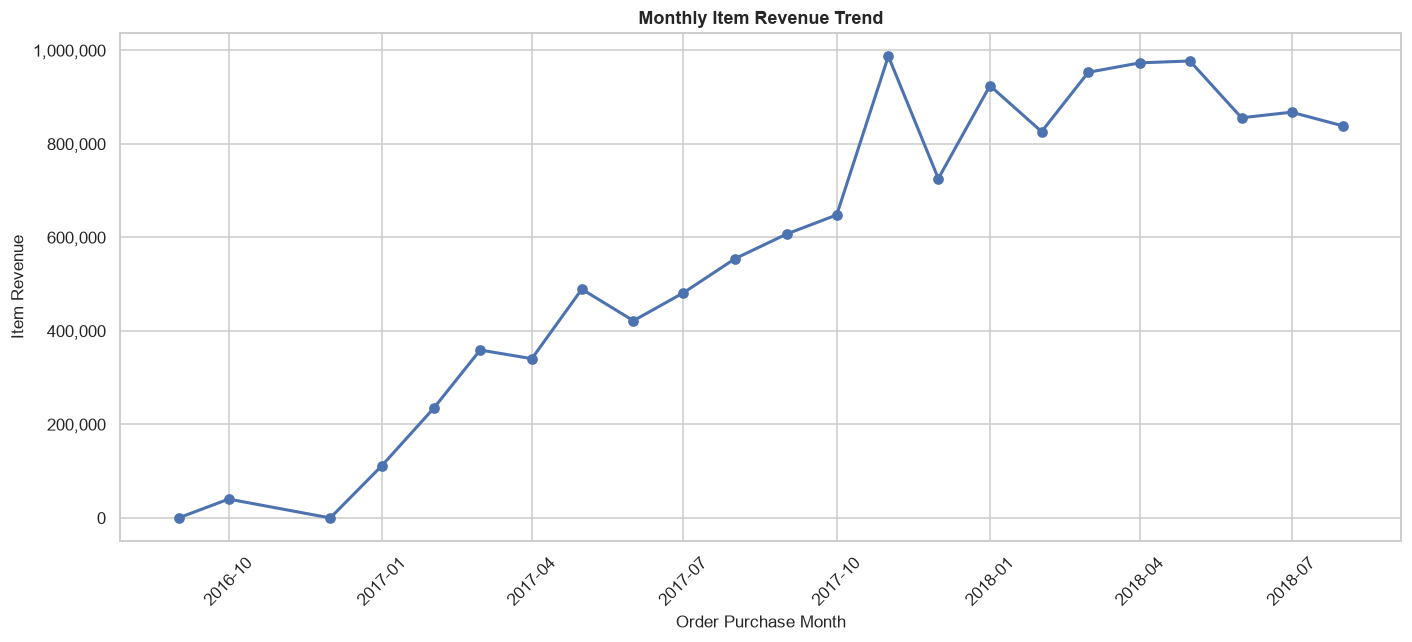

In [83]:
# 3. Chart 1 — Monthly item revenue trend
# Business question: How does item revenue change over time?
# A line chart helps identify trends, peaks, declines, and possible seasonal patterns.

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    monthly_sales["order_month"],
    monthly_sales["item_revenue"],
    marker="o",
    linewidth=2
)

ax.set_title("Monthly Item Revenue Trend")
ax.set_xlabel("Order Purchase Month")
ax.set_ylabel("Item Revenue")
ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter("{x:,.0f}")
)

plt.xticks(rotation=45)
plt.tight_layout()

fig.savefig(
    IMAGES_DIR / "monthly_item_revenue.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

How to interpret it:
- Identify the months with the highest and lowest revenue.
- Look for sustained increases or decreases.
- Check whether revenue changes correspond to changes in order count or AOV.

Do not call a single peak a seasonal trend without comparing the same period across multiple years.

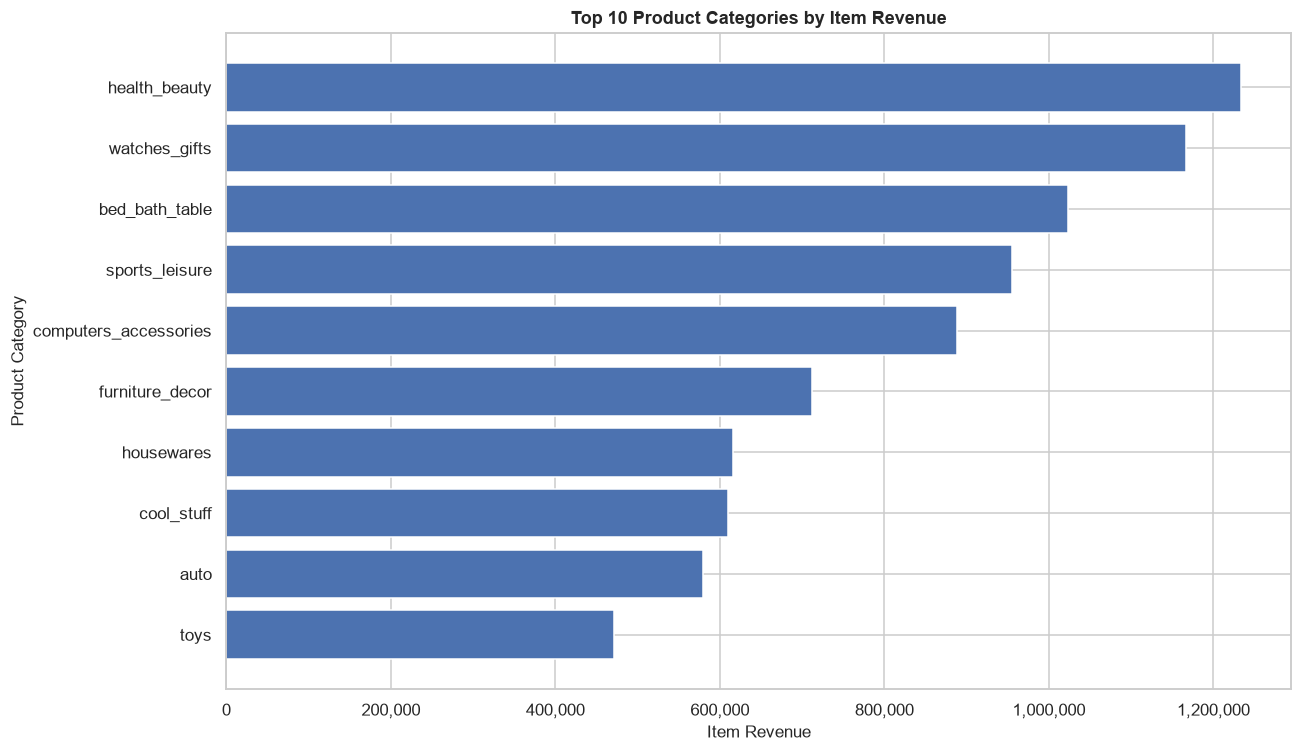

In [84]:
# 4. Chart 2 — Top 10 product categories
# Business question: Which product categories contribute the most item revenue?

top_categories = (
    category_performance
    .nlargest(10, "item_revenue")
    .sort_values("item_revenue")
)

fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(
    top_categories["category"],
    top_categories["item_revenue"]
)

ax.set_title("Top 10 Product Categories by Item Revenue")
ax.set_xlabel("Item Revenue")
ax.set_ylabel("Product Category")
ax.xaxis.set_major_formatter(
    mtick.StrMethodFormatter("{x:,.0f}")
)

plt.tight_layout()

fig.savefig(
    IMAGES_DIR / "top_categories.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

A horizontal bar chart makes long category names easier to read.
Interpretation: Identify the highest-revenue category and compare the gap between the top categories. High item revenue does not necessarily mean high profit.

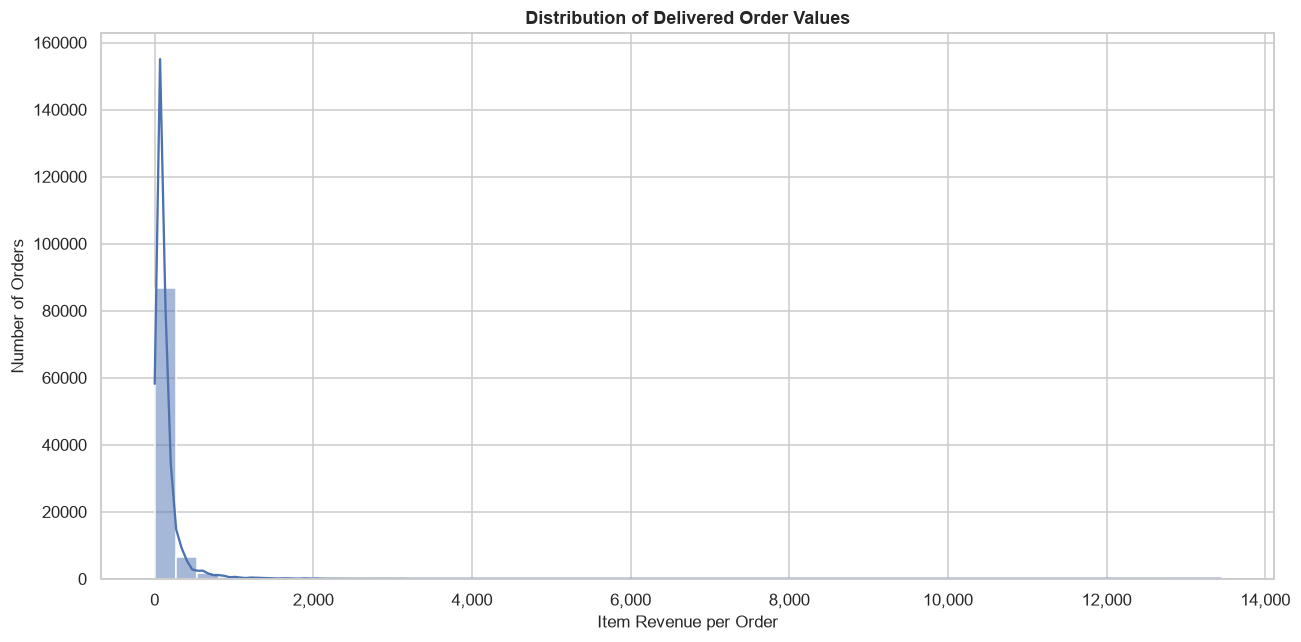

In [85]:
# 5. Chart 3 — Order value distribution
# Business question: Are most orders low-value, or are order values spread evenly?

fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(
    data=delivered_orders,
    x="item_revenue",
    bins=50,
    kde=True,
    ax=ax
)

ax.set_title("Distribution of Delivered Order Values")
ax.set_xlabel("Item Revenue per Order")
ax.set_ylabel("Number of Orders")
ax.xaxis.set_major_formatter(
    mtick.StrMethodFormatter("{x:,.0f}")
)

plt.tight_layout()

fig.savefig(
    IMAGES_DIR / "order_value_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

Interpretation:
- A long tail to the right indicates a small number of high-value orders.
- Compare the mean and median you calculated in Part 4.
- If the plot is heavily skewed, many orders may be concentrated in the lower-value range.

If high-value orders make the main distribution hard to see, use a second chart zoomed to a percentile range. Don't silently remove high-value orders from your analysis.

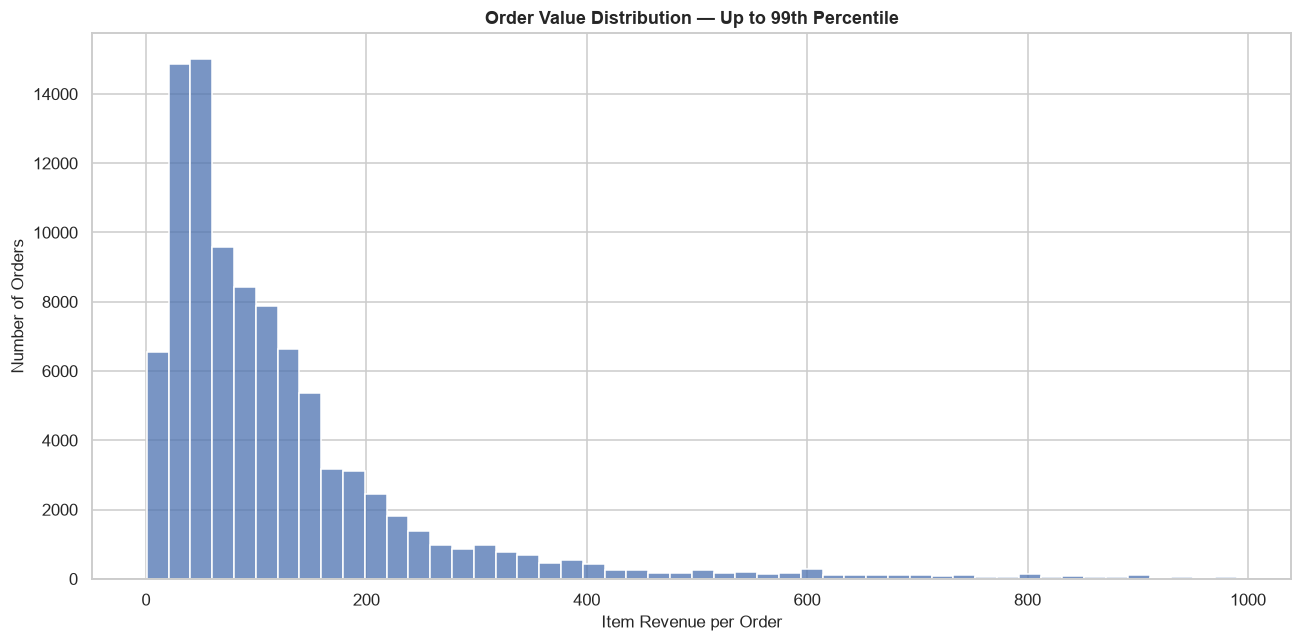

In [86]:
upper_limit = delivered_orders["item_revenue"].quantile(0.99)

fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(
    data=delivered_orders[
        delivered_orders["item_revenue"] <= upper_limit
    ],
    x="item_revenue",
    bins=50,
    ax=ax
)

ax.set_title("Order Value Distribution — Up to 99th Percentile")
ax.set_xlabel("Item Revenue per Order")
ax.set_ylabel("Number of Orders")

plt.tight_layout()

fig.savefig(
    IMAGES_DIR / "order_value_distribution_trimmed.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

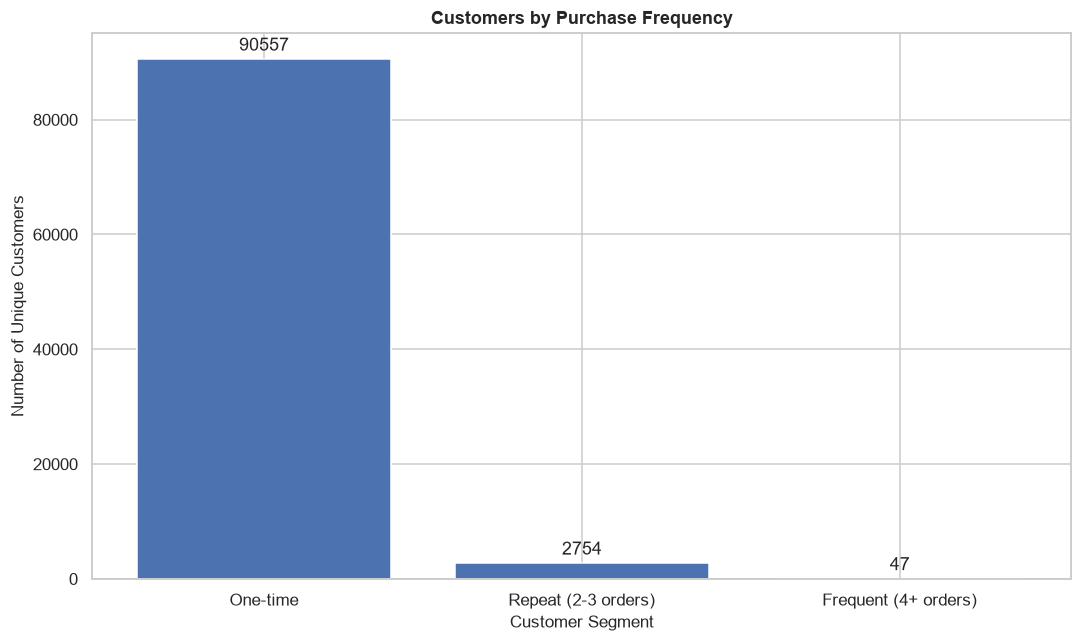

In [ ]:
# 6. Chart 4 — Customer purchase segments
# Business question: What proportion of customers are one-time, repeat, or frequent purchasers?
segment_order = [
    "One-time",
    "Repeat (2-3 orders)",
    "Frequent (4+ orders)"
]

customer_segments_plot = customer_segments.copy()

customer_segments_plot["purchase_segment"] = pd.Categorical(
    customer_segments_plot["purchase_segment"],
    categories=segment_order,
    ordered=True
)

customer_segments_plot = customer_segments_plot.sort_values(
    "purchase_segment"
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    customer_segments_plot["purchase_segment"].astype(str),
    customer_segments_plot["customers"]
)

ax.set_title("Customers by Purchase Frequency")
ax.set_xlabel("Customer Segment")
ax.set_ylabel("Number of Unique Customers")

ax.bar_label(bars, fmt="%.0f", padding=3)

plt.tight_layout()

fig.savefig(
    IMAGES_DIR / "customer_segments.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

Interpretation:
- Which segment contains the largest number of customers?
- How large is the frequent-purchaser segment compared with the one-time segment?
- Compare these counts with customer_share_pct and revenue_share_pct from your customer-segment table.

The chart describes observed purchases during the dataset period, not customers' complete lifetime behavior.

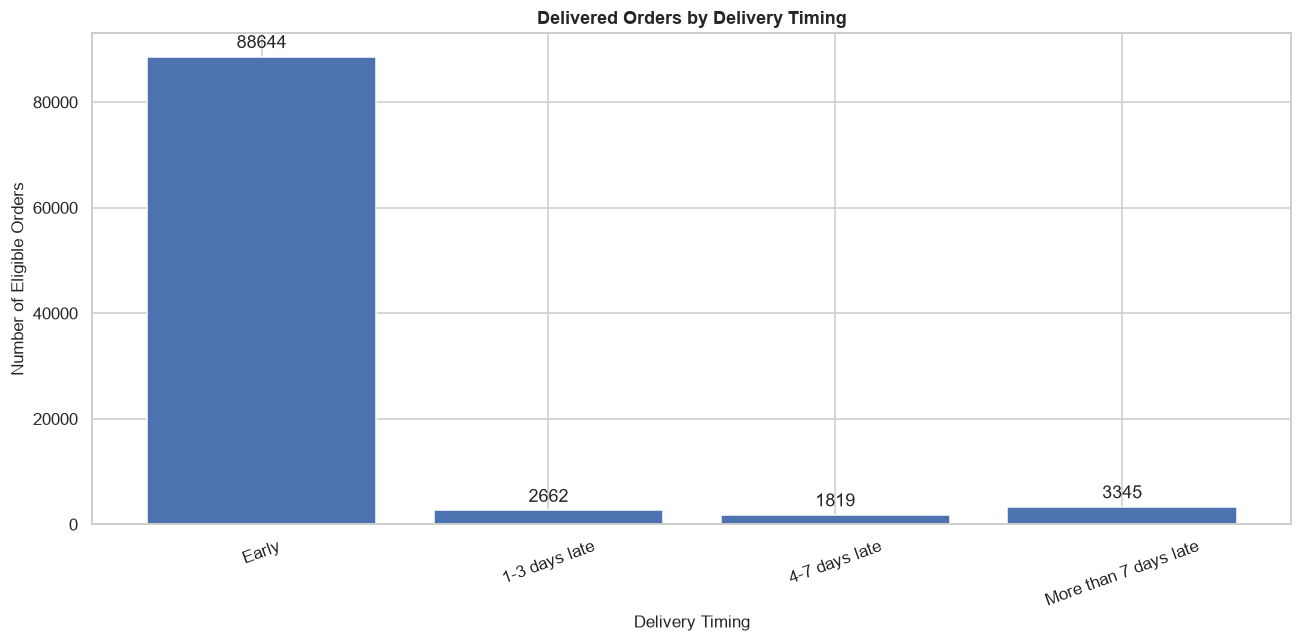

In [87]:
# 7. Chart 5 — Delivery-delay distribution
# Business question: How many delivered orders arrived early, on time, or late?

delay_order = [
    "Early",
    "On estimated date",
    "1-3 days late",
    "4-7 days late",
    "More than 7 days late"
]

delay_plot = delay_performance.copy()

delay_plot["delay_bucket"] = pd.Categorical(
    delay_plot["delay_bucket"],
    categories=delay_order,
    ordered=True
)

delay_plot = delay_plot.sort_values("delay_bucket")

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    delay_plot["delay_bucket"].astype(str),
    delay_plot["orders"]
)

ax.set_title("Delivered Orders by Delivery Timing")
ax.set_xlabel("Delivery Timing")
ax.set_ylabel("Number of Eligible Orders")
ax.tick_params(axis="x", rotation=20)

ax.bar_label(bars, fmt="%.0f", padding=3)

plt.tight_layout()

fig.savefig(
    IMAGES_DIR / "delivery_delay_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

Interpretation:
- Which delay group has the largest number of orders?
- How many orders were more than seven days late?
- Use the order_share_pct column to compare percentages rather than just counts.

All orders in this chart have both actual and estimated delivery dates.

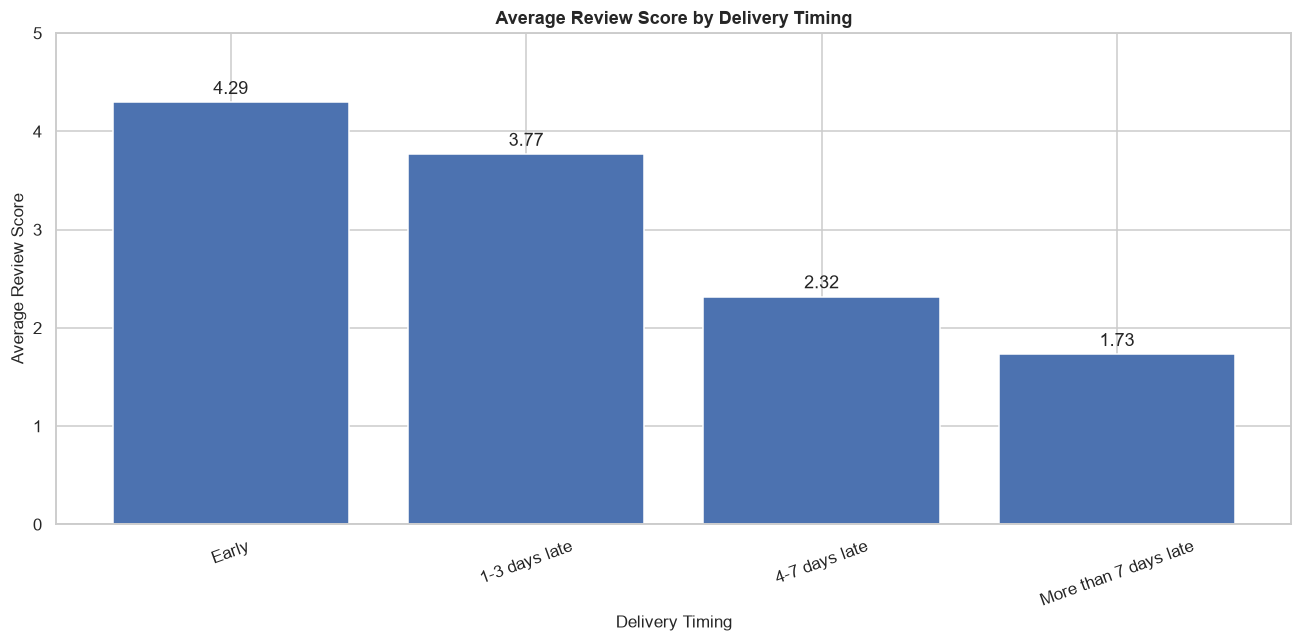

In [88]:
# 8. Chart 6 — Review scores by delivery delay
# Business question: Are average review scores different across delivery-delay groups?

review_plot = delay_review_performance.dropna(
    subset=["avg_review_score"]
).copy()

review_plot["delay_bucket"] = pd.Categorical(
    review_plot["delay_bucket"],
    categories=delay_order,
    ordered=True
)

review_plot = review_plot.sort_values("delay_bucket")

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    review_plot["delay_bucket"].astype(str),
    review_plot["avg_review_score"]
)

ax.set_title("Average Review Score by Delivery Timing")
ax.set_xlabel("Delivery Timing")
ax.set_ylabel("Average Review Score")
ax.set_ylim(0, 5)
ax.tick_params(axis="x", rotation=20)

ax.bar_label(bars, fmt="%.2f", padding=3)

plt.tight_layout()

fig.savefig(
    IMAGES_DIR / "review_scores_by_delivery_delay.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

Interpretation:
- Compare average review scores between early and late deliveries.
- Check the number of orders and reviews in each group before drawing conclusions.
- Remember that this is an association, not evidence that delivery delays caused a particular rating.

The average is calculated from available order-level review scores. Orders without reviews do not contribute to the average.

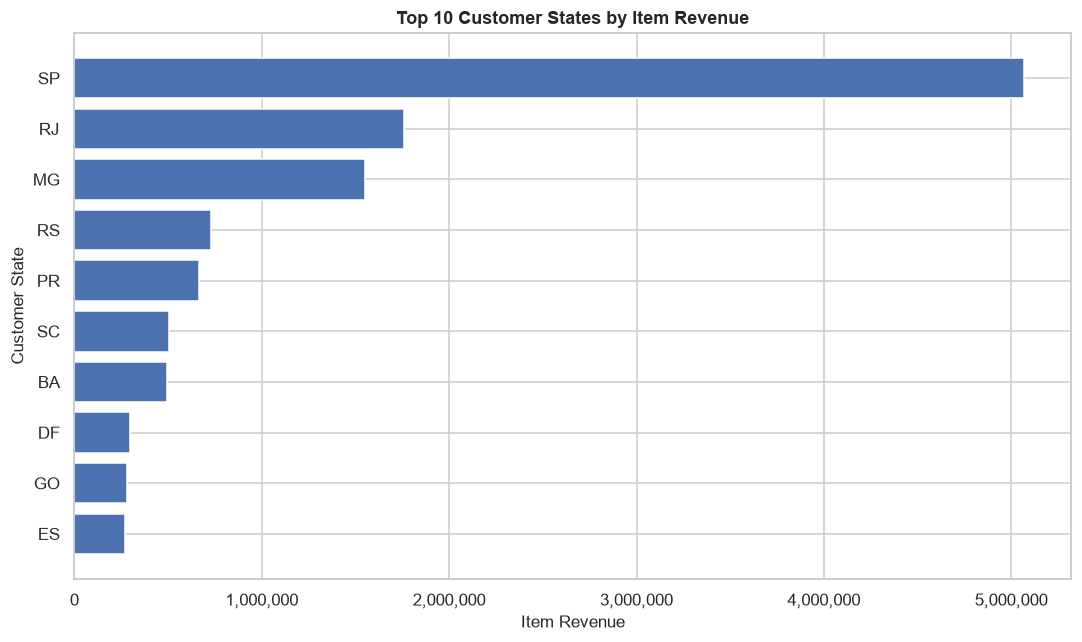

In [89]:
# 9. Chart 7 — Top 10 customer states by item revenue
# Business question: Which customer states account for the largest item revenue?

top_states = (
    state_performance
    .nlargest(10, "item_revenue")
    .sort_values("item_revenue")
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top_states["customer_state"],
    top_states["item_revenue"]
)

ax.set_title("Top 10 Customer States by Item Revenue")
ax.set_xlabel("Item Revenue")
ax.set_ylabel("Customer State")
ax.xaxis.set_major_formatter(
    mtick.StrMethodFormatter("{x:,.0f}")
)

plt.tight_layout()

fig.savefig(
    IMAGES_DIR / "top_states.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

Interpretation: Compare the state ranking by revenue with its ranking by order count. States with more orders may generate more revenue, but differences in AOV can also matter.

In [82]:
# 10. Save the charts for your portfolio
IMAGES_DIR = PROJECT_DIR / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

For each chart you want to save, insert plt.savefig(...) after creating the chart and before plt.show().
For example, for the monthly revenue chart:

# Power BI Export Preparation.

In [90]:
# Create the order-level fact table
fact_orders = order_master.copy()

# Add month for time-based analysis
fact_orders["order_month"] = (
    pd.to_datetime(
        fact_orders["order_purchase_timestamp"], errors="coerce"
    ).dt.to_period("M").dt.to_timestamp()
)

# Delivery duration in days
fact_orders["delivery_days"] = (
    fact_orders["order_delivered_customer_date"]
    - fact_orders["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

# Delivery delay relative to the estimated date
fact_orders["delivery_delay_days"] = (
    fact_orders["order_delivered_customer_date"]
    - fact_orders["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 60 * 60)

# Late-delivery flag; unknown if required dates are missing
fact_orders["is_late"] = pd.Series(
    pd.NA, index=fact_orders.index, dtype="boolean"
)

valid_delivery_dates = (
    fact_orders["order_delivered_customer_date"].notna()
    & fact_orders["order_estimated_delivery_date"].notna()
)

fact_orders.loc[valid_delivery_dates, "is_late"] = (
    fact_orders.loc[
        valid_delivery_dates, "order_delivered_customer_date"
    ]
    > fact_orders.loc[
        valid_delivery_dates, "order_estimated_delivery_date"
    ]
).values

# Check grain
assert fact_orders["order_id"].is_unique
assert len(fact_orders) == len(order_master)

print("Fact orders shape:", fact_orders.shape)
print("Unique orders:", fact_orders["order_id"].nunique())
print("Order status distribution:")
display(fact_orders["order_status"].value_counts(dropna=False))

Fact orders shape: (99441, 27)
Unique orders: 99441
Order status distribution:


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [92]:
# Start with the delivered item-level analysis table
fact_order_items = items_with_products.copy()

# Prepare seller dimension
dim_sellers = sellers[
    ["seller_id", "seller_zip_code_prefix",
     "seller_city", "seller_state"]
].drop_duplicates(subset=["seller_id"]).copy()

# Add seller location to each item
fact_order_items = fact_order_items.merge(
    dim_sellers[["seller_id", "seller_state"]],
    on="seller_id",
    how="left",
    validate="many_to_one"
)

# Keep useful columns, retaining only those that exist
item_columns = [
    "order_id", "order_item_id", "product_id", "seller_id",
    "price", "freight_value", "product_category_name",
    "product_category_name_english", "seller_state"
]

item_columns = [
    col for col in item_columns
    if col in fact_order_items.columns
]

fact_order_items = fact_order_items[item_columns].copy()

# Validate the item-line grain
assert not fact_order_items.duplicated(
    subset=["order_id", "order_item_id"]
).any()

print("Fact order items shape:", fact_order_items.shape)
print("Unique item lines:",
      fact_order_items[["order_id", "order_item_id"]]
      .drop_duplicates().shape[0])

display(fact_order_items.head())

Fact order items shape: (110197, 9)
Unique item lines: 110197


,order_id,order_item_id,product_id,seller_id,price,freight_value,product_category_name,product_category_name_english,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,58.90,13.29,cool_stuff,cool_stuff,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,239.90,19.93,pet_shop,pet_shop,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,199.00,17.87,moveis_decoracao,furniture_decor,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,12.99,12.79,perfumaria,perfumery,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,199.90,18.14,ferramentas_jardim,garden_tools,PR


In [93]:
# Step 4: Prepare product and seller dimensions
# 4A. Product dimension
# Add English category names to product details
dim_products = products_clean.merge(
    category_translation,
    on="product_category_name",
    how="left",
    validate="many_to_one"
)

# Use English translation when available; otherwise retain original
dim_products["category_name"] = (
    dim_products["product_category_name_english"]
    .fillna(dim_products["product_category_name"])
)

assert dim_products["product_id"].is_unique

print("Product dimension shape:", dim_products.shape)
display(dim_products.head())

Product dimension shape: (32951, 11)


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,category_name
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00,perfumery,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,"1,000.00",30.00,18.00,20.00,art,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00,sports_leisure,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00,baby,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00,housewares,housewares


In [94]:
# 4B. Seller dimension
#The seller dimension was prepared in Step 3. Verify it:
assert dim_sellers["seller_id"].is_unique

print("Seller dimension shape:", dim_sellers.shape)
display(dim_sellers.head())

Seller dimension shape: (3095, 4)


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [95]:
# Step 5: Export all Power BI datasets
# Create a dedicated folder for the exported files:
POWERBI_DIR = PROCESSED_DIR / "powerbi"
POWERBI_DIR.mkdir(parents=True, exist_ok=True)

In [96]:
# Now export the tables. This saves a separate copy; it does not modify your raw CSV files.
# Main fact and dimension tables
exports = {
    "fact_orders.csv": fact_orders,
    "fact_order_items.csv": fact_order_items,
    "dim_products.csv": dim_products,
    "dim_sellers.csv": dim_sellers,

    # Aggregate analysis tables created in Part 5
    "monthly_sales.csv": monthly_sales,
    "category_performance.csv": category_performance,
    "seller_performance.csv": seller_performance,
    "customer_segments.csv": customer_segments,
    "customer_gap_summary.csv": customer_gap_summary,
    "delay_performance.csv": delay_performance,
    "delay_review_performance.csv": delay_review_performance,
}

for filename, df in exports.items():
    df.to_csv(
        POWERBI_DIR / filename,
        index=False,
        encoding="utf-8"
    )
    print(f"Exported: {filename} | {len(df):,} rows")

Exported: fact_orders.csv | 99,441 rows
Exported: fact_order_items.csv | 110,197 rows
Exported: dim_products.csv | 32,951 rows
Exported: dim_sellers.csv | 3,095 rows
Exported: monthly_sales.csv | 23 rows
Exported: category_performance.csv | 74 rows
Exported: seller_performance.csv | 2,970 rows
Exported: customer_segments.csv | 3 rows
Exported: customer_gap_summary.csv | 2,801 rows
Exported: delay_performance.csv | 4 rows
Exported: delay_review_performance.csv | 4 rows


Note: fact_orders.csv is at order grain, while fact_order_items.csv is at item-line grain. Do not directly sum order-level values after joining them to multiple item rows. In Power BI, we’ll establish relationships carefully and use measures appropriate to each grain.

In [97]:
#Step 6: Validate the exported files
#Never assume a file is correct just because it was exported successfully.
#Run this validation cell:
import os

validation_results = []

for filename, original_df in exports.items():
    file_path = POWERBI_DIR / filename
    exported_df = pd.read_csv(file_path)

    validation_results.append({
        "file": filename,
        "exists": file_path.exists(),
        "original_rows": len(original_df),
        "exported_rows": len(exported_df),
        "row_count_matches": len(original_df) == len(exported_df),
        "file_size_kb": round(os.path.getsize(file_path) / 1024, 2),
        "columns": len(exported_df.columns)
    })

export_validation = pd.DataFrame(validation_results)
display(export_validation)

assert export_validation["exists"].all()
assert export_validation["row_count_matches"].all()

print("All exported files passed existence and row-count checks.")

,file,exists,original_rows,exported_rows,row_count_matches,file_size_kb,columns
0,fact_orders.csv,True,99441,99441,True,"31,203.81",27
1,fact_order_items.csv,True,110197,110197,True,"15,691.93",9
2,dim_products.csv,True,32951,32951,True,"3,644.51",11
3,dim_sellers.csv,True,3095,3095,True,162.78,4
4,monthly_sales.csv,True,23,23,True,2.83,9
5,category_performance.csv,True,74,74,True,4.96,7
6,seller_performance.csv,True,2970,2970,True,167.44,6
7,customer_segments.csv,True,3,3,True,0.41,7
8,customer_gap_summary.csv,True,2801,2801,True,196.00,4
9,delay_performance.csv,True,4,4,True,0.28,4


All exported files passed existence and row-count checks.


In [98]:
# Then check the key fields separately:
# One row per order
assert fact_orders["order_id"].is_unique

# One row per item line
assert not fact_order_items.duplicated(
    ["order_id", "order_item_id"]
).any()

# One row per product and seller
assert dim_products["product_id"].is_unique
assert dim_sellers["seller_id"].is_unique

print("Grain and primary-key checks passed.")

Grain and primary-key checks passed.


In [99]:
# Step 7: Generate actual Python findings
# Your report should use the real results from your notebook—not example numbers or assumed trends.
total_orders = len(delivered_orders)
total_item_revenue = delivered_orders["item_revenue"].sum()
total_freight = delivered_orders["freight_revenue"].sum()
aov = (
    total_item_revenue / total_orders
    if total_orders else np.nan
)

repeat_customer_rate = customer_summary[
    "repeat_customer"
].mean() * 100

avg_review_score = delivered_orders[
    "average_review_score"
].mean()

delivery_rate = (
    eligible_delivery["is_late"].eq(False).mean() * 100
    if len(eligible_delivery) else np.nan
)

print(f"Delivered orders: {total_orders:,}")
print(f"Item revenue: {total_item_revenue:,.2f}")
print(f"Freight revenue: {total_freight:,.2f}")
print(f"Average order value (item revenue only): {aov:,.2f}")
print(f"Repeat customer rate: {repeat_customer_rate:.2f}%")
print(f"Average review score: {avg_review_score:.2f}")
print(f"On-time delivery rate: {delivery_rate:.2f}%")

Delivered orders: 96,478
Item revenue: 13,221,498.11
Freight revenue: 2,198,275.64
Average order value (item revenue only): 137.04
Repeat customer rate: 3.00%
Average review score: 4.16
On-time delivery rate: 91.89%
